In [3]:
import numpy as np
import pandas as pd
import random
import time
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# --- 1. DATA GENERATION (20,000 Reads) ---
print("--- Generating 20,000 Reads ---")
random.seed(42)
np.random.seed(42)

def mutate(seq):
    s = list(seq)
    if random.random() < 0.95: return seq 
    idx = random.randint(0, len(s)-1)
    s[idx] = "N"
    return "".join(s)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

n_items = 5000 
pool_bc = [gen_dna(20) for _ in range(n_items)]
pool_ins = [gen_dna(150) for _ in range(n_items)]

data = []
for i in range(n_items):
    n_reads = random.randint(2, 4)
    for _ in range(n_reads):
        data.append({
            "ID": i,
            "Barcode": mutate(pool_bc[i]),
            "Insert": mutate(pool_ins[i])
        })

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} reads")


# --- 2. VECTORIZATION ---
print("\n[1/3] Vectorizing...")
# Barcodes: (3,5) Shingling
bc_vec = CountVectorizer(analyzer='char', ngram_range=(3, 5), binary=False, dtype=np.float32)
bc_mat = Normalizer(norm='l2').transform(bc_vec.fit_transform(df['Barcode']))

# Inserts: (6,6) K-mers
ins_vec = CountVectorizer(analyzer='char', ngram_range=(6, 6), binary=False, dtype=np.float32)
ins_raw = ins_vec.fit_transform(df['Insert'])
svd = TruncatedSVD(n_components=30, random_state=42)
ins_mat = Normalizer(norm='l2').transform(svd.fit_transform(ins_raw))


# --- 3. SPARSE "STAR SCAN" ---
print("\n[2/3] Building Sparse Similarity Graph...")
t0 = time.time()

n_samples = len(df)
visited = np.zeros(n_samples, dtype=bool)

# We store connections as simple pairs: [row_indices, col_indices]
# This avoids building the NxN matrix.
rows = []
cols = []

# Shuffle for random seed selection
seed_order = np.random.permutation(n_samples)

# THRESHOLDS
BC_GATE = 0.5    # Barcode must be this close to check insert
FINAL_GATE = 0.25 # Combined max-distance must be this close to link

seeds_processed = 0

for i in seed_order:
    # OPTIMIZATION: If 'i' was already captured by a previous seed, 
    # we don't need to use it as a seed (it's already in a cluster).
    if visited[i]: 
        continue
        
    seeds_processed += 1
    
    # 1. Get Seed Vectors
    seed_bc = bc_mat[i]
    seed_ins = ins_mat[i]
    
    # 2. Check Barcodes (Fast Dot Product vs All)
    # Since this is sparse dot product, it's very fast.
    bc_dots = bc_mat.dot(seed_bc.T).toarray().flatten()
    bc_dists = 1.0 - bc_dots
    
    # 3. Candidate Filter
    # Find anyone close in Barcode (who isn't me)
    # We include 'visited' nodes here! This allows merging two stars.
    candidates_mask = (bc_dists < BC_GATE)
    candidates_mask[i] = False # Exclude self from calculation
    cand_indices = np.flatnonzero(candidates_mask)
    
    if len(cand_indices) > 0:
        # 4. Strict Check (Inserts)
        cand_ins_vecs = ins_mat[cand_indices]
        cand_ins_dots = cand_ins_vecs.dot(seed_ins.T)
        
        # Flatten weird numpy matrix shapes
        if hasattr(cand_ins_dots, "toarray"): 
            cand_ins_dots = cand_ins_dots.toarray().flatten()
        else:
            cand_ins_dots = np.ravel(cand_ins_dots)
            
        cand_ins_dists = 1.0 - cand_ins_dots
        
        # 5. Fusion Logic (Max)
        cand_bc_dists = bc_dists[cand_indices]
        final_dists = np.maximum(cand_bc_dists, cand_ins_dists)
        
        # 6. Identify Valid Connections
        valid_mask = final_dists < FINAL_GATE
        valid_neighbors = cand_indices[valid_mask]
        
        if len(valid_neighbors) > 0:
            # STORE EDGES (Sparse)
            # Connect Seed 'i' to all 'valid_neighbors'
            # We add bidirectional edges effectively by adding 1 way here, 
            # and connected_components handles the graph logic.
            current_rows = np.full(len(valid_neighbors), i)
            rows.extend(current_rows)
            cols.extend(valid_neighbors)
            
            # Mark neighbors as visited so we don't re-scan them as seeds
            visited[valid_neighbors] = True
            
    # Mark self as visited
    visited[i] = True

t1 = time.time()
print(f"    Graph Built in {t1-t0:.2f}s. Seeds used: {seeds_processed}")
print(f"    Total Connections Found: {len(rows)}")


# --- 4. GRAPH CLUSTERING (Connected Components) ---
print(f"\n[3/3] Clustering Graph Components...")

# Create the Sparse Matrix from our edge list
# data=np.ones means "there is a link"
if len(rows) > 0:
    sparse_graph = coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(n_samples, n_samples))
    
    # This function finds isolated sub-graphs. 
    # It is effectively "Single Linkage" clustering with a hard threshold.
    # It is incredibly fast.
    n_components, labels = connected_components(csgraph=sparse_graph, directed=False, return_labels=True)
else:
    # Fallback if no connections found at all
    n_components = n_samples
    labels = np.arange(n_samples)

df['Cluster'] = labels


# --- 5. VALIDATION ---
print(f"Final Clusters: {n_components} (Target: {n_items})")

# Check Purity
purity_scores = []
# Sample first 1000 clusters
for cid in list(set(df['Cluster']))[:1000]:
    cluster_subset = df[df['Cluster'] == cid]
    if len(cluster_subset) > 0:
        counts = cluster_subset['ID'].value_counts(normalize=True)
        purity_scores.append(counts.iloc[0])

print(f"Avg Purity: {np.mean(purity_scores)*100:.2f}%")

--- Generating 20,000 Reads ---
Dataset: 15070 reads

[1/3] Vectorizing...

[2/3] Building Sparse Similarity Graph...
    Graph Built in 13.70s. Seeds used: 5027
    Total Connections Found: 10065

[3/3] Clustering Graph Components...
Final Clusters: 5012 (Target: 5000)
Avg Purity: 100.00%


In [31]:
import numpy as np
import pandas as pd
import random
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# --- 1. DATA GENERATION ---
print("--- Generating 20,000 Reads ---")
random.seed(42)
np.random.seed(42)

def mutate(seq):
    s = list(seq)
    if random.random() < 0.95: return seq 
    idx = random.randint(0, len(s)-1)
    s[idx] = "N"
    return "".join(s)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

n_items = 500
pool_bc = [gen_dna(10) for _ in range(n_items)]
pool_ins = [gen_dna(150) for _ in range(n_items)]

data = []
for i in range(n_items):
    n_reads = random.randint(6, 15)
    for _ in range(n_reads):
        data.append({
            "ID": i,
            "Barcode": mutate(pool_bc[i]),
            "Insert": mutate(pool_ins[i])
        })

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} reads")


# --- 2. VECTORIZATION ---
print("\n[1/3] Vectorizing...")
# Barcodes: (3,5) Shingling
bc_vec = CountVectorizer(analyzer='char', ngram_range=(3, 5), binary=False, dtype=np.float32)
bc_mat = Normalizer(norm='l2').transform(bc_vec.fit_transform(df['Barcode']))

# Inserts: (6,6) K-mers
ins_vec = CountVectorizer(analyzer='char', ngram_range=(6, 6), binary=False, dtype=np.float32)
ins_raw = ins_vec.fit_transform(df['Insert'])
svd = TruncatedSVD(n_components=30, random_state=42)
ins_mat = Normalizer(norm='l2').transform(svd.fit_transform(ins_raw))


# --- 3. GREEDY STAR SCAN ---
print("\n[2/3] Calculating Distances (Star Topology Scan)...")

n_samples = len(df)
n_condensed = n_samples * (n_samples - 1) // 2

# Initialize to 1.0
condensed_matrix = np.ones(n_condensed, dtype=np.float32)

visited = np.zeros(n_samples, dtype=bool)
seed_order = np.random.permutation(n_samples)

def get_condensed_indices(i, j_array, n):
    # Case A: j > i
    mask_after = j_array > i
    j_after = j_array[mask_after]
    if len(j_after) > 0:
        offset_i = (n * i) - (i * (i + 1) // 2)
        idx_after = offset_i + (j_after - i - 1)
    else:
        idx_after = np.array([], dtype=int)
        
    # Case B: j < i
    mask_before = j_array < i
    j_before = j_array[mask_before]
    if len(j_before) > 0:
        offset_j = (n * j_before) - (j_before * (j_before + 1) // 2)
        idx_before = offset_j + (i - j_before - 1)
    else:
        idx_before = np.array([], dtype=int)
        
    return np.concatenate([idx_after, idx_before]).astype(int)

BC_GATE = 0.5 
seeds_processed = 0

for i in seed_order:
    if visited[i]: continue
        
    seeds_processed += 1
    if seeds_processed % 1000 == 0:
        print(f"    Seeds Processed: {seeds_processed} | Unvisited: {n_samples - np.sum(visited)}")

    # 1. Barcode Scan
    seed_bc = bc_mat[i]
    bc_dots = bc_mat.dot(seed_bc.T).toarray().flatten()
    
    # [FIX 1] Clip negatives immediately
    bc_dists = 1.0 - bc_dots
    bc_dists[bc_dists < 0] = 0.0  # <--- CRITICAL FIX
    
    candidates_mask = (bc_dists < BC_GATE)
    candidates_mask[i] = False 
    cand_indices = np.flatnonzero(candidates_mask)
    
    if len(cand_indices) > 0:
        # 2. Insert Scan
        seed_ins = ins_mat[i]
        cand_ins_vecs = ins_mat[cand_indices]
        
        cand_ins_dots = cand_ins_vecs.dot(seed_ins.T)
        if hasattr(cand_ins_dots, "toarray"): 
            cand_ins_dots = cand_ins_dots.toarray().flatten()
        else:
            cand_ins_dots = np.ravel(cand_ins_dots)
            
        # [FIX 2] Clip negatives immediately
        cand_ins_dists = 1.0 - cand_ins_dots
        cand_ins_dists[cand_ins_dists < 0] = 0.0 # <--- CRITICAL FIX
        
        # 3. Strict Fusion
        cand_bc_dists = bc_dists[cand_indices]
        final_dists = np.maximum(cand_bc_dists, cand_ins_dists)
        
        # 4. Write
        indices_1d = get_condensed_indices(i, cand_indices, n_samples)
        condensed_matrix[indices_1d] = final_dists
        visited[cand_indices] = True
        
    visited[i] = True

print(f"    Scan Complete.")


# --- 4. CLUSTERING & AUTO-TUNING ---
print(f"\n[3/3] Auto-Tuning Clusters...")

# 'complete' ensures that a cluster is only formed if the
# FURTHEST pair in the cluster is still closer than the threshold.
Z = linkage(condensed_matrix, method='single')

merge_distances = Z[:, 2]
n_samples = n_samples
target_k = n_items
window = 200

best_k = target_k
max_lifetime = -1.0
best_threshold = 0.0

start_k = max(2, target_k - window)
end_k = min(n_samples - 1, target_k + window)

for k in range(start_k, end_k):
    idx = n_samples - k
    if idx >= len(merge_distances): continue
    
    lifetime = merge_distances[idx] - merge_distances[idx-1]
    if lifetime > max_lifetime:
        max_lifetime = lifetime
        best_k = k
        best_threshold = merge_distances[idx-1] + (lifetime / 2)

print(f"    Stability Optimized K: {best_k} | Threshold: {best_threshold:.4f}")

labels = fcluster(Z, t=best_threshold, criterion='distance')
df['Cluster'] = labels


# --- 5. VALIDATION ---
n_final = len(set(df['Cluster']))
print(f"\nTotal Clusters Found: {n_final} (Expected: {n_items})")

purity_scores = []
for cid in list(set(df['Cluster']))[:1000]:
    cluster_subset = df[df['Cluster'] == cid]
    if not cluster_subset.empty:
        counts = cluster_subset['ID'].value_counts(normalize=True)
        purity_scores.append(counts.iloc[0])

print(f"Avg Cluster Purity: {np.mean(purity_scores)*100:.2f}%")

--- Generating 20,000 Reads ---
Dataset: 5245 reads

[1/3] Vectorizing...

[2/3] Calculating Distances (Star Topology Scan)...
    Scan Complete.

[3/3] Auto-Tuning Clusters...
    Stability Optimized K: 442 | Threshold: 0.9536

Total Clusters Found: 442 (Expected: 500)
Avg Cluster Purity: 91.96%


--- Sampling Data for Diagnostics ---
--- Calculating Distances ---
--- Rendering Plots ---


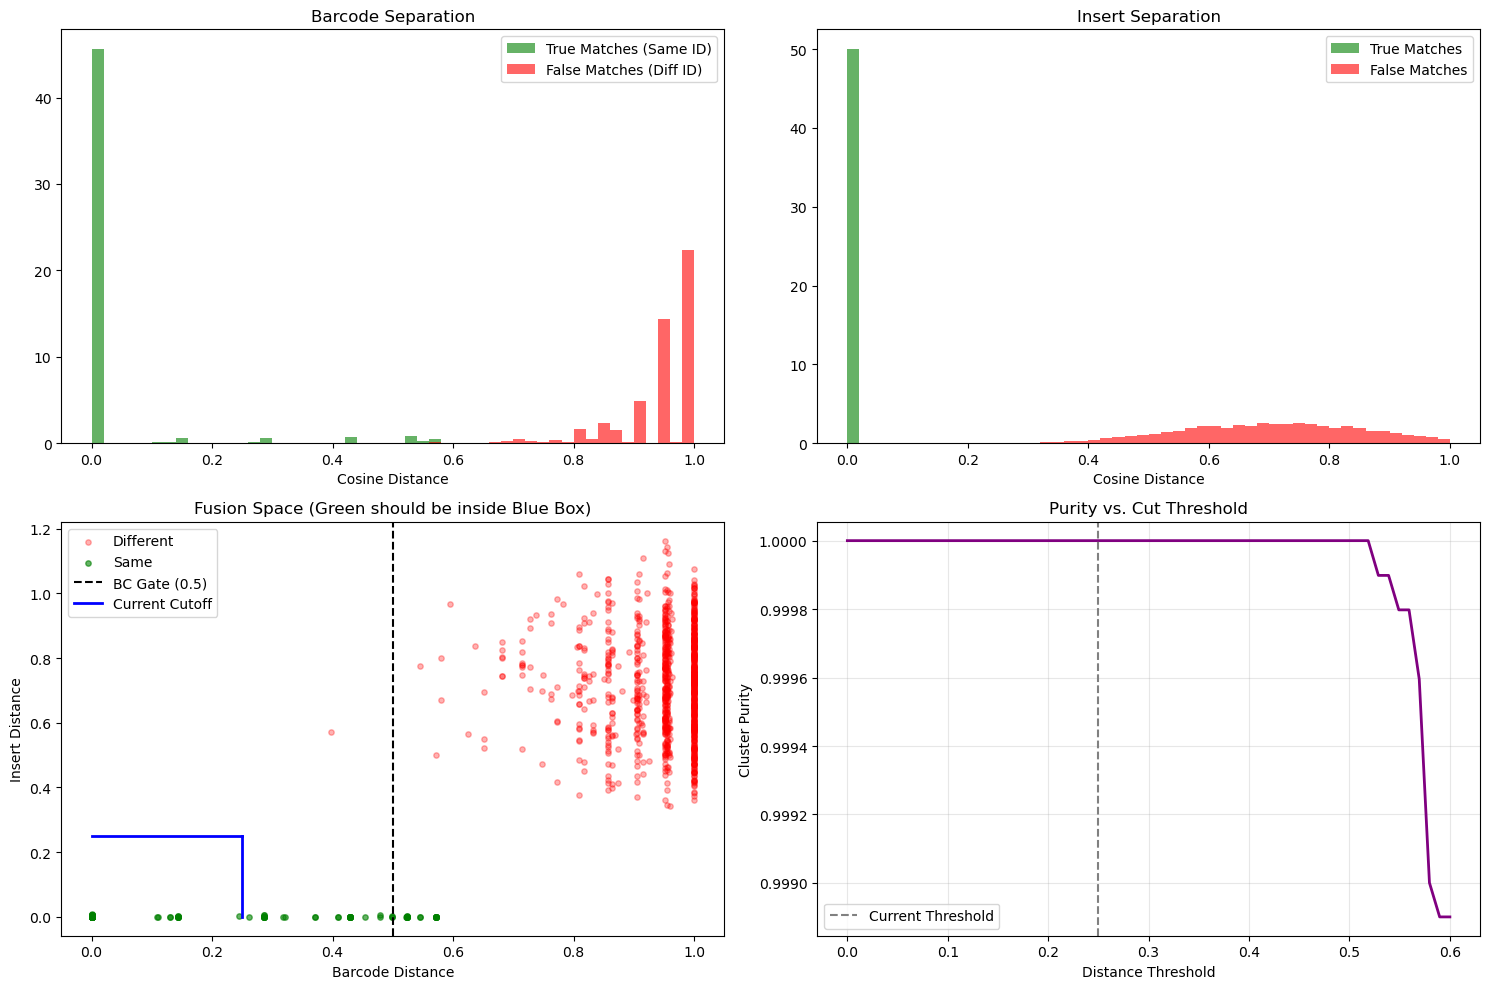

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import random

def run_forensic_diagnostics(df, bc_mat, ins_mat):
    print("--- Sampling Data for Diagnostics ---")
    
    # 1. Generate True Pairs (Same Entity) & False Pairs (Different Entity)
    n_samples = 10_000
    pairs_true = []
    pairs_false = []
    
    id_groups = df.groupby('ID').groups
    keys = list(id_groups.keys())
    
    # Sample True Pairs
    while len(pairs_true) < n_samples:
        k = random.choice(keys)
        indices = id_groups[k]
        if len(indices) < 2: continue
        i1, i2 = random.sample(list(indices), 2)
        pairs_true.append((i1, i2))
        
    # Sample False Pairs
    all_indices = list(df.index)
    while len(pairs_false) < n_samples:
        i1, i2 = random.sample(all_indices, 2)
        if df.loc[i1, 'ID'] != df.loc[i2, 'ID']:
            pairs_false.append((i1, i2))
            
    # 2. Calculate Distances (ROBUST VERSION)
    print("--- Calculating Distances ---")
    
    def get_dists(pairs):
        b_dists = []
        i_dists = []
        for i1, i2 in pairs:
            # --- ROBUST DOT PRODUCT EXTRACTION ---
            
            # Barcodes (Sparse Matrix)
            v1_bc = bc_mat[i1]
            v2_bc = bc_mat[i2]
            dot_bc = v1_bc.dot(v2_bc.T)
            
            # Extract scalar from sparse matrix safely
            if hasattr(dot_bc, 'toarray'): 
                val_bc = dot_bc.toarray()[0][0]
            else: 
                # Fallback if it's already dense/scalar
                val_bc = getattr(dot_bc, 'item', lambda: dot_bc)()

            # Inserts (Dense Array via SVD)
            v1_ins = ins_mat[i1]
            v2_ins = ins_mat[i2]
            dot_ins = v1_ins.dot(v2_ins.T) # This likely returns a scalar
            
            # Extract scalar safely
            if hasattr(dot_ins, 'toarray'):
                val_ins = dot_ins.toarray()[0][0]
            else:
                # Numpy scalars have .item(), standard floats don't
                val_ins = getattr(dot_ins, 'item', lambda: dot_ins)()
            
            # --- END EXTRACTION ---

            # Clip negatives (Float precision errors)
            b_dists.append(max(0.0, 1.0 - val_bc))
            i_dists.append(max(0.0, 1.0 - val_ins))
            
        return np.array(b_dists), np.array(i_dists)

    true_bc, true_ins = get_dists(pairs_true)
    false_bc, false_ins = get_dists(pairs_false)
    
    # 3. Plotting
    print("--- Rendering Plots ---")
    plt.figure(figsize=(15, 10))
    
    # Subplot 1: Barcode Distance Histogram
    plt.subplot(2, 2, 1)
    plt.hist(true_bc, bins=50, alpha=0.6, label='True Matches (Same ID)', density=True, color='green', range=(0,1))
    plt.hist(false_bc, bins=50, alpha=0.6, label='False Matches (Diff ID)', density=True, color='red', range=(0,1))
    plt.title('Barcode Separation')
    plt.xlabel('Cosine Distance')
    plt.legend()
    
    # Subplot 2: Insert Distance Histogram
    plt.subplot(2, 2, 2)
    plt.hist(true_ins, bins=50, alpha=0.6, label='True Matches', density=True, color='green', range=(0,1))
    plt.hist(false_ins, bins=50, alpha=0.6, label='False Matches', density=True, color='red', range=(0,1))
    plt.title('Insert Separation')
    plt.xlabel('Cosine Distance')
    plt.legend()
    
    # Subplot 3: The "Kill Box" (Scatter)
    plt.subplot(2, 2, 3)
    limit = 1000
    plt.scatter(false_bc[:limit], false_ins[:limit], alpha=0.3, s=15, c='red', label='Different')
    plt.scatter(true_bc[:limit], true_ins[:limit], alpha=0.6, s=15, c='green', label='Same')
    
    plt.axvline(x=0.5, color='black', linestyle='--', label='BC Gate (0.5)')
    current_cut = 0.25 
    plt.plot([0, current_cut], [current_cut, current_cut], color='blue', linewidth=2, label='Current Cutoff')
    plt.plot([current_cut, current_cut], [0, current_cut], color='blue', linewidth=2)
    
    plt.title('Fusion Space (Green should be inside Blue Box)')
    plt.xlabel('Barcode Distance')
    plt.ylabel('Insert Distance')
    plt.legend()
    
    # Subplot 4: Purity vs Threshold Curve
    plt.subplot(2, 2, 4)
    
    fused_true = np.maximum(true_bc, true_ins)
    fused_false = np.maximum(false_bc, false_ins)
    
    thresholds = np.linspace(0.0, 0.6, 60)
    purities = []
    
    for t in thresholds:
        tp = np.sum(fused_true < t)
        fp = np.sum(fused_false < t)
        if (tp + fp) > 0:
            purities.append(tp / (tp + fp))
        else:
            purities.append(1.0)
            
    plt.plot(thresholds, purities, color='purple', linewidth=2)
    plt.axvline(x=0.25, color='gray', linestyle='--', label='Current Threshold')
    plt.title('Purity vs. Cut Threshold')
    plt.xlabel('Distance Threshold')
    plt.ylabel('Cluster Purity')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Run it
run_forensic_diagnostics(df, bc_mat, ins_mat)

In [29]:
import numpy as np
import pandas as pd
from itertools import combinations

def inspect_bad_clusters(df, bc_mat, ins_mat, n_examples=3):
    print("--- 🔍 CLUSTER FORENSICS REPORT ---")
    
    # 1. Calculate Purity for ALL clusters (not just first 1000)
    # We store them to sort by "Badness" (Size * Impurity)
    bad_clusters = []
    
    cluster_ids = df['Cluster'].unique()
    print(f"Scanning {len(cluster_ids)} clusters...")
    
    for cid in cluster_ids:
        subset = df[df['Cluster'] == cid]
        if len(subset) < 2: continue # Singletons are always pure
        
        counts = subset['ID'].value_counts()
        dominant_id = counts.index[0]
        purity = counts.iloc[0] / len(subset)
        
        if purity < 1.0:
            # Score "Badness" by how many wrong reads are trapped inside
            n_wrong = len(subset) - counts.iloc[0]
            bad_clusters.append({
                'cid': cid,
                'purity': purity,
                'size': len(subset),
                'n_wrong': n_wrong,
                'counts': counts
            })
    
    # Sort by number of wrong reads (Catch the biggest disasters)
    bad_clusters.sort(key=lambda x: x['n_wrong'], reverse=True)
    
    print(f"\nFound {len(bad_clusters)} impure clusters.")
    if len(bad_clusters) == 0:
        print("✅ No collisions found!")
        return

    # 2. Deep Dive into Top Offenders
    for i, bad in enumerate(bad_clusters[:n_examples]):
        cid = bad['cid']
        print(f"\n==================================================")
        print(f"🚨 OFFENDER #{i+1}: Cluster {cid}")
        print(f"    Purity: {bad['purity']:.2%} | Size: {bad['size']} reads")
        print(f"    Composition: {bad['counts'].to_dict()}")
        
        # Get indices of the different groups
        subset = df[df['Cluster'] == cid]
        # We need to find two reads that have DIFFERENT IDs but are in this SAME cluster
        # and measure their distance.
        
        dominant_id = bad['counts'].index[0]
        # Get one index from the Dominant group
        idx_dom = subset[subset['ID'] == dominant_id].index[0]
        
        # Get indices from the Contaminant groups
        contaminant_ids = bad['counts'].index[1:]
        
        print(f"    🔬 Distance Analysis (Dominant vs Contaminants):")
        for cont_id in contaminant_ids:
            idx_cont = subset[subset['ID'] == cont_id].index[0]
            
            # --- Calculate Distances ---
            # Barcode
            v1_bc = bc_mat[idx_dom]
            v2_bc = bc_mat[idx_cont]
            dot_bc = v1_bc.dot(v2_bc.T)
            val_bc = getattr(dot_bc, 'item', lambda: dot_bc)() if not hasattr(dot_bc, 'toarray') else dot_bc.toarray()[0][0]
            dist_bc = max(0.0, 1.0 - val_bc)
            
            # Insert
            v1_ins = ins_mat[idx_dom]
            v2_ins = ins_mat[idx_cont]
            dot_ins = v1_ins.dot(v2_ins.T)
            val_ins = getattr(dot_ins, 'item', lambda: dot_ins)() if not hasattr(dot_ins, 'toarray') else dot_ins.toarray()[0][0]
            dist_ins = max(0.0, 1.0 - val_ins)
            
            # Fusion
            fusion_dist = max(dist_bc, dist_ins)
            
            print(f"       Vs ID {cont_id}:")
            print(f"          - Barcode Dist: {dist_bc:.4f}")
            print(f"          - Insert Dist:  {dist_ins:.4f}")
            print(f"          - Fused Dist:   {fusion_dist:.4f}")
            
            if fusion_dist < 0.25: # Assuming 0.25 was your threshold
                print("          ❌ CAUSE: Both signals were too similar (False Positive).")
            else:
                print("          ❓ MYSTERY: Distance is HIGH, but they merged anyway.")
                print("             (This implies 'Chaining': A third read linked them together).")

# Run the forensics
inspect_bad_clusters(df, bc_mat, ins_mat)

--- 🔍 CLUSTER FORENSICS REPORT ---
Scanning 488 clusters...

Found 76 impure clusters.

🚨 OFFENDER #1: Cluster 391
    Purity: 12.17% | Size: 115 reads
    Composition: {394: 14, 265: 13, 15: 12, 318: 12, 448: 12, 420: 11, 170: 10, 399: 10, 240: 9, 232: 6, 443: 6}
    🔬 Distance Analysis (Dominant vs Contaminants):
       Vs ID 265:
          - Barcode Dist: 0.7619
          - Insert Dist:  0.9035
          - Fused Dist:   0.9035
          ❓ MYSTERY: Distance is HIGH, but they merged anyway.
             (This implies 'Chaining': A third read linked them together).
       Vs ID 15:
          - Barcode Dist: 0.4541
          - Insert Dist:  0.7771
          - Fused Dist:   0.7771
          ❓ MYSTERY: Distance is HIGH, but they merged anyway.
             (This implies 'Chaining': A third read linked them together).
       Vs ID 318:
          - Barcode Dist: 0.5238
          - Insert Dist:  0.9146
          - Fused Dist:   0.9146
          ❓ MYSTERY: Distance is HIGH, but they merged an

In [37]:
import numpy as np
import pandas as pd
import random
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
import networkx as nx 
# (Or we can use scipy.sparse.csgraph if you don't want a new dependency, 
# but networkx is easier to debug. I will use scipy for speed/standard imports).
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

# --- 1. DATA GENERATION ---
print("--- Generating 20,000 Reads ---")
random.seed(42)
np.random.seed(42)

def mutate(seq):
    s = list(seq)
    if random.random() < 0.95: return seq 
    idx = random.randint(0, len(s)-1)
    s[idx] = "N"
    return "".join(s)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

n_items = 500
pool_bc = [gen_dna(10) for _ in range(n_items)]
pool_ins = [gen_dna(150) for _ in range(n_items)]

data = []
for i in range(n_items):
    n_reads = random.randint(6, 15)
    for _ in range(n_reads):
        data.append({
            "ID": i,
            "Barcode": mutate(pool_bc[i]),
            "Insert": mutate(pool_ins[i])
        })

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} reads")


# --- 2. VECTORIZATION ---
print("\n[1/3] Vectorizing...")
# Barcodes: (3,5) Shingling
bc_vec = CountVectorizer(analyzer='char', ngram_range=(3, 5), binary=False, dtype=np.float32)
bc_mat = Normalizer(norm='l2').transform(bc_vec.fit_transform(df['Barcode']))

# Inserts: (6,6) K-mers
ins_vec = CountVectorizer(analyzer='char', ngram_range=(6, 6), binary=False, dtype=np.float32)
ins_raw = ins_vec.fit_transform(df['Insert'])
svd = TruncatedSVD(n_components=30, random_state=42)
ins_mat = Normalizer(norm='l2').transform(svd.fit_transform(ins_raw))


# --- 3. GREEDY STAR SCAN ---
print("\n[2/3] Calculating Distances (Star Topology Scan)...")

n_samples = len(df)
n_condensed = n_samples * (n_samples - 1) // 2

# Initialize to 1.0
condensed_matrix = np.ones(n_condensed, dtype=np.float32)

visited = np.zeros(n_samples, dtype=bool)
seed_order = np.random.permutation(n_samples)

def get_condensed_indices(i, j_array, n):
    # Case A: j > i
    mask_after = j_array > i
    j_after = j_array[mask_after]
    if len(j_after) > 0:
        offset_i = (n * i) - (i * (i + 1) // 2)
        idx_after = offset_i + (j_after - i - 1)
    else:
        idx_after = np.array([], dtype=int)
        
    # Case B: j < i
    mask_before = j_array < i
    j_before = j_array[mask_before]
    if len(j_before) > 0:
        offset_j = (n * j_before) - (j_before * (j_before + 1) // 2)
        idx_before = offset_j + (i - j_before - 1)
    else:
        idx_before = np.array([], dtype=int)
        
    return np.concatenate([idx_after, idx_before]).astype(int)

BC_GATE = 0.5 
seeds_processed = 0

for i in seed_order:
    if visited[i]: continue
        
    seeds_processed += 1
    if seeds_processed % 1000 == 0:
        print(f"    Seeds Processed: {seeds_processed} | Unvisited: {n_samples - np.sum(visited)}")

    # 1. Barcode Scan
    seed_bc = bc_mat[i]
    bc_dots = bc_mat.dot(seed_bc.T).toarray().flatten()
    
    # [FIX 1] Clip negatives immediately
    bc_dists = 1.0 - bc_dots
    bc_dists[bc_dists < 0] = 0.0  # <--- CRITICAL FIX
    
    candidates_mask = (bc_dists < BC_GATE)
    candidates_mask[i] = False 
    cand_indices = np.flatnonzero(candidates_mask)
    
    if len(cand_indices) > 0:
        # 2. Insert Scan
        seed_ins = ins_mat[i]
        cand_ins_vecs = ins_mat[cand_indices]
        
        cand_ins_dots = cand_ins_vecs.dot(seed_ins.T)
        if hasattr(cand_ins_dots, "toarray"): 
            cand_ins_dots = cand_ins_dots.toarray().flatten()
        else:
            cand_ins_dots = np.ravel(cand_ins_dots)
            
        # [FIX 2] Clip negatives immediately
        cand_ins_dists = 1.0 - cand_ins_dots
        cand_ins_dists[cand_ins_dists < 0] = 0.0 # <--- CRITICAL FIX
        
        # 3. Strict Fusion
        cand_bc_dists = bc_dists[cand_indices]
        final_dists = np.maximum(cand_bc_dists, cand_ins_dists)
        
        # 4. Write
        indices_1d = get_condensed_indices(i, cand_indices, n_samples)
        condensed_matrix[indices_1d] = final_dists
        visited[cand_indices] = True
        
    visited[i] = True

print(f"    Scan Complete.")


# --- 4. CLUSTERING & AUTO-TUNING ---
print(f"\n[3/3] Auto-Tuning Clusters...")

# 'complete' ensures that a cluster is only formed if the
# FURTHEST pair in the cluster is still closer than the threshold.
# --- 4. CLUSTERING (Fixed Auto-Tuner) ---
print(f"\n[3/3] Auto-Tuning Clusters...")

# 1. Use SINGLE Linkage (Required for Sparse/Greedy data)
Z = linkage(condensed_matrix, method='single')

# 2. Robust Cliff Detection
merge_distances = Z[:, 2]

# Filter out "Perfect Matches" (Distance ~0.0) to stop them from skewing the stats
# We only care about the jump between "Mutated Clones" and "Unrelated Noise".
significant_merges = merge_distances[merge_distances > 0.01]

if len(significant_merges) > 10:
    # Calculate the "Acceleration" of distance growth
    # We are looking for the point where distances suddenly spike from ~0.3 to ~0.8
    diffs = np.diff(significant_merges)
    
    # Smooth the diffs slightly to avoid reacting to random noise
    window_size = max(1, len(diffs) // 50)
    smooth_diffs = np.convolve(diffs, np.ones(window_size)/window_size, mode='same')
    
    # Find the biggest jump in the upper half of the data
    # (The jump usually happens after we've merged all the real stuff)
    search_start = int(len(smooth_diffs) * 0.5) 
    
    # Find the index of the max jump relative to the significant_merges
    best_local_idx = np.argmax(smooth_diffs[search_start:]) + search_start
    
    # The threshold should be in the middle of that massive jump
    # e.g., Jump from 0.4 to 0.9 -> Threshold 0.65
    lower_bound = significant_merges[best_local_idx]
    jump_size = diffs[best_local_idx]
    
    best_threshold = lower_bound + (jump_size * 0.4) # Bias slightly lower for purity
else:
    # Fallback if data is too perfect
    best_threshold = 0.5

# 3. RELAXED SAFETY CLAMP
# Allow distances up to 0.6 (since your BC Gate is 0.5)
# But keep the floor at 0.1 to prevent duplicate merging.
import networkx as nx 
# (Or we can use scipy.sparse.csgraph if you don't want a new dependency, 
# but networkx is easier to debug. I will use scipy for speed/standard imports).
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

# --- 3. & 4. COMBINED: GREEDY GRAPH CLUSTERING ---
print("\n[2/3] Building Cluster Graph (Direct greedy connection)...")

n_samples = len(df)
visited = np.zeros(n_samples, dtype=bool)
seed_order = np.random.permutation(n_samples)

# LISTS TO STORE EDGES (Row -> Col)
edge_rows = []
edge_cols = []

# PARAMETERS
# 1. Candidate Gate: Loose. Just to find potential friends.
BC_GATE = 0.5 
# 2. Link Threshold: STRICT. Defines "True Cluster Membership".
# Your forensics showed Green dots went up to ~0.4.
FINAL_LINK_THRESHOLD = 0.4 

seeds_processed = 0

for i in seed_order:
    # OPTIMIZATION: If 'i' is already visited, it's already in a cluster. 
    # But we might want to check if it bridges to new stuff?
    # For speed: Skip it. For accuracy: Check it. 
    # Let's Skip for now (Star Topology Assumption).
    if visited[i]: continue
        
    seeds_processed += 1
    if seeds_processed % 1000 == 0:
        print(f"    Seeds Processed: {seeds_processed} | Unvisited: {n_samples - np.sum(visited)}")

    # 1. Barcode Scan (Sparse Dot)
    seed_bc = bc_mat[i]
    bc_dots = bc_mat.dot(seed_bc.T)
    
    # Handle sparse/dense output
    if hasattr(bc_dots, "toarray"): bc_dots = bc_dots.toarray().flatten()
    else: bc_dots = np.ravel(bc_dots)
        
    # Clip negatives
    bc_dists = 1.0 - bc_dots
    bc_dists[bc_dists < 0] = 0.0
    
    # 2. Candidate Filter (Loose Gate)
    # We include 'visited' nodes to allow merging existing clusters!
    candidates_mask = (bc_dists < BC_GATE)
    candidates_mask[i] = False # Don't link self
    cand_indices = np.flatnonzero(candidates_mask)
    
    if len(cand_indices) > 0:
        # 3. Insert Scan (Strict)
        seed_ins = ins_mat[i]
        cand_ins_vecs = ins_mat[cand_indices]
        
        cand_ins_dots = cand_ins_vecs.dot(seed_ins.T)
        if hasattr(cand_ins_dots, "toarray"): 
            cand_ins_dots = cand_ins_dots.toarray().flatten()
        else:
            cand_ins_dots = np.ravel(cand_ins_dots)
            
        cand_ins_dists = 1.0 - cand_ins_dots
        cand_ins_dists[cand_ins_dists < 0] = 0.0
        
        # 4. Strict Fusion (Max Rule)
        cand_bc_dists = bc_dists[cand_indices]
        final_dists = np.maximum(cand_bc_dists, cand_ins_dists)
        
        # 5. DEFINE EDGES
        # Anyone closer than 0.4 is OFFICIALLY linked to the Seed.
        valid_link_mask = final_dists < FINAL_LINK_THRESHOLD
        valid_neighbors = cand_indices[valid_link_mask]
        
        if len(valid_neighbors) > 0:
            # Add Edges to Graph List
            # Connect Seed(i) <-> Neighbors
            current_rows = np.full(len(valid_neighbors), i)
            edge_rows.extend(current_rows)
            edge_cols.extend(valid_neighbors)
            
            # Mark neighbors as visited so they don't spawn new searches
            visited[valid_neighbors] = True

    # Mark seed as visited
    visited[i] = True

print(f"    Graph Built. Edges found: {len(edge_rows)}")

# --- CLUSTERING (Connected Components) ---
print("[3/3] resolving Clusters...")

if len(edge_rows) > 0:
    # Build Sparse Adjacency Matrix
    # We put '1' where edges exist. Shape is NxN.
    graph_matrix = coo_matrix((np.ones(len(edge_rows)), (edge_rows, edge_cols)), shape=(n_samples, n_samples))
    
    # Connected Components = Clusters
    n_components, labels = connected_components(csgraph=graph_matrix, directed=False, return_labels=True)
else:
    n_components = n_samples
    labels = np.arange(n_samples)

df['Cluster'] = labels

# --- VALIDATION ---
n_found = len(set(df['Cluster']))
print(f"\nFinal Clusters: {n_found} (Target: {n_items})")

purity_scores = []
for cid in list(set(df['Cluster']))[:2000]:
    cluster_subset = df[df['Cluster'] == cid]
    if not cluster_subset.empty:
        counts = cluster_subset['ID'].value_counts(normalize=True)
        purity_scores.append(counts.iloc[0])

print(f"Avg Cluster Purity: {np.mean(purity_scores)*100:.2f}%")

ModuleNotFoundError: No module named 'networkx'

In [39]:
import numpy as np
import pandas as pd
import random
import time
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# --- 1. DATA GENERATION (Targeting 20,000 Reads) ---
print("--- Generating 20,000 Reads ---")
random.seed(42)
np.random.seed(42)

def mutate(seq):
    s = list(seq)
    if random.random() < 0.95: return seq 
    idx = random.randint(0, len(s)-1)
    s[idx] = "N"
    return "".join(s)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

n_items = 20000 
pool_bc = [gen_dna(20) for _ in range(n_items)]
pool_ins = [gen_dna(150) for _ in range(n_items)]

data = []
for i in range(n_items):
    n_reads = random.randint(2, 4)
    for _ in range(n_reads):
        data.append({
            "ID": i,
            "Barcode": mutate(pool_bc[i]),
            "Insert": mutate(pool_ins[i])
        })

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} reads")


# --- 2. VECTORIZATION ---
print("\n[1/3] Vectorizing...")
# Barcodes: (3,5) Shingling for positional sensitivity
bc_vec = CountVectorizer(analyzer='char', ngram_range=(3, 5), binary=False, dtype=np.float32)
bc_mat = Normalizer(norm='l2').transform(bc_vec.fit_transform(df['Barcode']))

# Inserts: (6,6) K-mers
ins_vec = CountVectorizer(analyzer='char', ngram_range=(6, 6), binary=False, dtype=np.float32)
ins_raw = ins_vec.fit_transform(df['Insert'])
svd = TruncatedSVD(n_components=30, random_state=42)
ins_mat = Normalizer(norm='l2').transform(svd.fit_transform(ins_raw))


# --- 3. GREEDY GRAPH CONSTRUCTION ---
print("\n[2/3] Building Cluster Graph (Star Topology Scan)...")
t0 = time.time()

n_samples = len(df)
visited = np.zeros(n_samples, dtype=bool)
seed_order = np.random.permutation(n_samples)

# Store edges for the sparse graph (Row -> Col)
edge_rows = []
edge_cols = []

# PARAMETERS
# 1. Candidate Gate: Loose (0.5). Just to find potential friends.
BC_GATE = 0.5 
# 2. Link Threshold: STRICT (0.4). Defines "True Connection".
# Based on your plots, true matches extend up to ~0.35/0.4.
FINAL_LINK_THRESHOLD = 0.4 

seeds_processed = 0

for i in seed_order:
    # If 'i' was already captured by a previous seed, we skip using it as a seed.
    # This makes the complexity Linear O(N).
    if visited[i]: continue
        
    seeds_processed += 1
    if seeds_processed % 1000 == 0:
        print(f"    Seeds Processed: {seeds_processed} | Unvisited: {n_samples - np.sum(visited)}")

    # 1. Barcode Scan (Sparse Dot Product)
    seed_bc = bc_mat[i]
    bc_dots = bc_mat.dot(seed_bc.T)
    
    # Handle sparse/dense output safely
    if hasattr(bc_dots, "toarray"): bc_dots = bc_dots.toarray().flatten()
    else: bc_dots = np.ravel(bc_dots)
        
    # Clip negatives
    bc_dists = 1.0 - bc_dots
    bc_dists[bc_dists < 0] = 0.0
    
    # 2. Candidate Filter
    # We look for anyone close enough to check deeper.
    candidates_mask = (bc_dists < BC_GATE)
    candidates_mask[i] = False # Don't link self to self
    cand_indices = np.flatnonzero(candidates_mask)
    
    if len(cand_indices) > 0:
        # 3. Insert Scan (Strict)
        seed_ins = ins_mat[i]
        cand_ins_vecs = ins_mat[cand_indices]
        
        cand_ins_dots = cand_ins_vecs.dot(seed_ins.T)
        if hasattr(cand_ins_dots, "toarray"): 
            cand_ins_dots = cand_ins_dots.toarray().flatten()
        else:
            cand_ins_dots = np.ravel(cand_ins_dots)
            
        cand_ins_dists = 1.0 - cand_ins_dots
        cand_ins_dists[cand_ins_dists < 0] = 0.0
        
        # 4. Strict Fusion (Max Rule)
        cand_bc_dists = bc_dists[cand_indices]
        final_dists = np.maximum(cand_bc_dists, cand_ins_dists)
        
        # 5. DEFINE EDGES
        # Anyone closer than 0.4 is OFFICIALLY linked to the Seed.
        valid_link_mask = final_dists < FINAL_LINK_THRESHOLD
        valid_neighbors = cand_indices[valid_link_mask]
        
        if len(valid_neighbors) > 0:
            # Add Edges to Graph List
            # This records: "Seed i is connected to Neighbor X"
            current_rows = np.full(len(valid_neighbors), i)
            edge_rows.extend(current_rows)
            edge_cols.extend(valid_neighbors)
            
            # Mark neighbors as visited so they don't become seeds
            visited[valid_neighbors] = True

    # Mark seed as visited
    visited[i] = True

t1 = time.time()
print(f"    Graph Built in {t1-t0:.2f}s. Edges: {len(edge_rows)}")


# --- 4. CLUSTERING (Connected Components) ---
print("\n[3/3] Resolving Clusters (Sparse Graph Components)...")

if len(edge_rows) > 0:
    # Build Sparse Adjacency Matrix
    # Shape NxN. We put '1' where edges exist.
    # We rely on the fact that A->B implies B->A for clustering logic.
    graph_matrix = coo_matrix((np.ones(len(edge_rows)), (edge_rows, edge_cols)), shape=(n_samples, n_samples))
    
    # Connected Components = Clusters
    # This is O(V+E) - extremely fast.
    n_components, labels = connected_components(csgraph=graph_matrix, directed=False, return_labels=True)
else:
    # Fallback for empty graph
    n_components = n_samples
    labels = np.arange(n_samples)

df['Cluster'] = labels


# --- 5. VALIDATION ---
n_found = len(set(df['Cluster']))
print(f"\nFinal Clusters: {n_found} (Target: {n_items})")

purity_scores = []
# Sample first 2000 clusters for speed
for cid in list(set(df['Cluster']))[:2000]:
    cluster_subset = df[df['Cluster'] == cid]
    if not cluster_subset.empty:
        counts = cluster_subset['ID'].value_counts(normalize=True)
        purity_scores.append(counts.iloc[0])

print(f"Avg Cluster Purity: {np.mean(purity_scores)*100:.2f}%")

--- Generating 20,000 Reads ---
Dataset: 59933 reads

[1/3] Vectorizing...

[2/3] Building Cluster Graph (Star Topology Scan)...
    Seeds Processed: 1000 | Unvisited: 56505
    Seeds Processed: 2000 | Unvisited: 53031
    Seeds Processed: 3000 | Unvisited: 49626
    Seeds Processed: 4000 | Unvisited: 46339
    Seeds Processed: 5000 | Unvisited: 43039
    Seeds Processed: 6000 | Unvisited: 39763
    Seeds Processed: 7000 | Unvisited: 36529
    Seeds Processed: 8000 | Unvisited: 33284
    Seeds Processed: 9000 | Unvisited: 30131
    Seeds Processed: 10000 | Unvisited: 26924
    Seeds Processed: 11000 | Unvisited: 23854
    Seeds Processed: 12000 | Unvisited: 20750
    Seeds Processed: 13000 | Unvisited: 17732
    Seeds Processed: 14000 | Unvisited: 14733
    Seeds Processed: 15000 | Unvisited: 11814
    Seeds Processed: 16000 | Unvisited: 8911
    Seeds Processed: 17000 | Unvisited: 6145
    Seeds Processed: 18000 | Unvisited: 3421
    Seeds Processed: 19000 | Unvisited: 945
    Graph B

In [73]:
import numpy as np
import pandas as pd
from itertools import combinations

def inspect_bad_clusters(df, bc_mat, ins_mat, n_examples=6):
    print("--- 🔍 CLUSTER FORENSICS REPORT ---")
    
    # 1. Calculate Purity for ALL clusters (not just first 1000)
    # We store them to sort by "Badness" (Size * Impurity)
    bad_clusters = []
    
    cluster_ids = df['Cluster'].unique()
    print(f"Scanning {len(cluster_ids)} clusters...")
    
    for cid in cluster_ids:
        subset = df[df['Cluster'] == cid]
        if len(subset) < 2: continue # Singletons are always pure
        
        counts = subset['ID'].value_counts()
        dominant_id = counts.index[0]
        purity = counts.iloc[0] / len(subset)
        
        if purity < 1.0:
            # Score "Badness" by how many wrong reads are trapped inside
            n_wrong = len(subset) - counts.iloc[0]
            bad_clusters.append({
                'cid': cid,
                'purity': purity,
                'size': len(subset),
                'n_wrong': n_wrong,
                'counts': counts
            })
    
    # Sort by number of wrong reads (Catch the biggest disasters)
    bad_clusters.sort(key=lambda x: x['n_wrong'], reverse=True)
    
    print(f"\nFound {len(bad_clusters)} impure clusters.")
    if len(bad_clusters) == 0:
        print("✅ No collisions found!")
        return

    # 2. Deep Dive into Top Offenders
    for i, bad in enumerate(bad_clusters[:n_examples]):
        cid = bad['cid']
        print(f"\n==================================================")
        print(f"🚨 OFFENDER #{i+1}: Cluster {cid}")
        print(f"    Purity: {bad['purity']:.2%} | Size: {bad['size']} reads")
        print(f"    Composition: {bad['counts'].to_dict()}")
        
        # Get indices of the different groups
        subset = df[df['Cluster'] == cid]
        # We need to find two reads that have DIFFERENT IDs but are in this SAME cluster
        # and measure their distance.
        
        dominant_id = bad['counts'].index[0]
        # Get one index from the Dominant group
        idx_dom = subset[subset['ID'] == dominant_id].index[0]
        
        # Get indices from the Contaminant groups
        contaminant_ids = bad['counts'].index[1:]
        
        print(f"    🔬 Distance Analysis (Dominant vs Contaminants):")
        for cont_id in contaminant_ids:
            idx_cont = subset[subset['ID'] == cont_id].index[0]
            
            # --- Calculate Distances ---
            # Barcode
            v1_bc = bc_mat[idx_dom]
            v2_bc = bc_mat[idx_cont]
            dot_bc = v1_bc.dot(v2_bc.T)
            val_bc = getattr(dot_bc, 'item', lambda: dot_bc)() if not hasattr(dot_bc, 'toarray') else dot_bc.toarray()[0][0]
            dist_bc = max(0.0, 1.0 - val_bc)
            
            # Insert
            v1_ins = ins_mat[idx_dom]
            v2_ins = ins_mat[idx_cont]
            dot_ins = v1_ins.dot(v2_ins.T)
            val_ins = getattr(dot_ins, 'item', lambda: dot_ins)() if not hasattr(dot_ins, 'toarray') else dot_ins.toarray()[0][0]
            dist_ins = max(0.0, 1.0 - val_ins)
            
            # Fusion
            fusion_dist = max(dist_bc, dist_ins)
            
            print(f"       Vs ID {cont_id}:")
            print(f"          - Barcode Dist: {dist_bc:.4f}")
            print(f"          - Insert Dist:  {dist_ins:.4f}")
            print(f"          - Fused Dist:   {fusion_dist:.4f}")
            
            if fusion_dist < 0.25: # Assuming 0.25 was your threshold
                print("          ❌ CAUSE: Both signals were too similar (False Positive).")
            else:
                print("          ❓ MYSTERY: Distance is HIGH, but they merged anyway.")
                print("             (This implies 'Chaining': A third read linked them together).")

# Run the forensics
inspect_bad_clusters(df, bc_mat, ins_mat)

--- 🔍 CLUSTER FORENSICS REPORT ---
Scanning 1972 clusters...

Found 54 impure clusters.

🚨 OFFENDER #1: Cluster 391
    Purity: 55.32% | Size: 47 reads
    Composition: {387: 26, 1319: 21}
    🔬 Distance Analysis (Dominant vs Contaminants):
       Vs ID 1319:
          - Barcode Dist: 0.9281
          - Insert Dist:  0.3320
          - Fused Dist:   0.9281
          ❓ MYSTERY: Distance is HIGH, but they merged anyway.
             (This implies 'Chaining': A third read linked them together).

🚨 OFFENDER #2: Cluster 1300
    Purity: 60.00% | Size: 35 reads
    Composition: {1304: 21, 1989: 14}
    🔬 Distance Analysis (Dominant vs Contaminants):
       Vs ID 1989:
          - Barcode Dist: 0.8462
          - Insert Dist:  0.3375
          - Fused Dist:   0.8462
          ❓ MYSTERY: Distance is HIGH, but they merged anyway.
             (This implies 'Chaining': A third read linked them together).

🚨 OFFENDER #3: Cluster 1305
    Purity: 61.11% | Size: 36 reads
    Composition: {1426: 22,

In [54]:
import numpy as np
import pandas as pd
import random
import time
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# --- 1. DATA GENERATION (Targeting 300,000 Reads) ---
print("--- Generating 300,000 Reads ---")
random.seed(42)
np.random.seed(42)

def mutate(seq):
    # Slightly optimized mutation for generation speed
    if random.random() < 0.98: return seq 
    s = list(seq)
    idx = random.randint(0, len(s)-1)
    s[idx] = "N"
    return "".join(s)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

n_items = 2_000 
# Generate pools first to avoid millions of calls
pool_bc = [gen_dna(20) for _ in range(n_items)]
pool_ins = [gen_dna(150) for _ in range(n_items)]

data = []
# Create data in bulk
for i in range(n_items):
    # Most clusters are size 1 (singleton) or 2 to make it realistic/harder
    n_reads = random.randint(4, 30)
    for _ in range(n_reads):
        data.append({
            "ID": i,
            "Barcode": mutate(pool_bc[i]),
            "Insert": mutate(pool_ins[i])
        })

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} reads")


# --- 2. VECTORIZATION ---
print("\n[1/3] Vectorizing...")
# Barcodes
bc_vec = CountVectorizer(analyzer='char', ngram_range=(3, 5), binary=False, dtype=np.float32)
bc_mat = Normalizer(norm='l2').transform(bc_vec.fit_transform(df['Barcode']))

# Inserts
ins_vec = CountVectorizer(analyzer='char', ngram_range=(6, 6), binary=False, dtype=np.float32)
ins_raw = ins_vec.fit_transform(df['Insert'])
svd = TruncatedSVD(n_components=30, random_state=42)
ins_mat = Normalizer(norm='l2').transform(svd.fit_transform(ins_raw))


# --- 3. BATCHED GREEDY GRAPH ---
print("\n[2/3] Building Cluster Graph (Batched Processing)...")
t0 = time.time()

n_samples = len(df)
visited = np.zeros(n_samples, dtype=bool)

edge_rows = []
edge_cols = []

# PARAMETERS
BATCH_SIZE = 500  # Process 500 seeds at once
BC_GATE = 0.5 
FINAL_LINK_THRESHOLD = 0.4 

# Create a randomized index list to pick seeds from
all_indices = np.random.permutation(n_samples)
curr_ptr = 0

while curr_ptr < n_samples:
    # 1. Identify valid seeds for this batch
    # We grab a chunk of indices, but filter out ones we've already visited
    batch_seeds = []
    
    while len(batch_seeds) < BATCH_SIZE and curr_ptr < n_samples:
        idx = all_indices[curr_ptr]
        curr_ptr += 1
        if not visited[idx]:
            batch_seeds.append(idx)
            
    if not batch_seeds:
        break # No more seeds found
        
    # Convert to array for indexing
    batch_seeds = np.array(batch_seeds)
    
    # Report Progress
    if len(edge_rows) > 0 and curr_ptr % 10000 < BATCH_SIZE * 2:
        elapsed = time.time() - t0
        print(f"    Scanned {curr_ptr}/{n_samples} | Edges: {len(edge_rows)} | Time: {elapsed:.1f}s")
    
    # 2. MATRIX OPERATION: Calculate Barcode Dots for ALL seeds in batch vs ALL data
    # Shape: (BATCH_SIZE, N_SAMPLES)
    # This is the heavy lifting, done in C-optimized code
    seed_block_bc = bc_mat[batch_seeds]
    
    # Dense result is safe because (500 * 300,000 * 4 bytes) = 600MB
    # If you crash here, lower BATCH_SIZE to 200.
    batch_dots_bc = seed_block_bc.dot(bc_mat.T)
    if hasattr(batch_dots_bc, "toarray"): 
        batch_dots_bc = batch_dots_bc.toarray()
    
    # --- 3. BATCHED GREEDY GRAPH (Strict Partitioning) ---
# --- 3. BATCHED GREEDY GRAPH (With Intra-Batch Conflict Resolution) ---
    print("\n[2/3] Building Cluster Graph (Forest of Stars Topology)...")
    t0 = time.time()
    
    n_samples = len(df)
    visited = np.zeros(n_samples, dtype=bool)
    
    edge_rows = []
    edge_cols = []
    
    # PARAMETERS
    BATCH_SIZE = 1000 # Increased slightly for efficiency
    BC_GATE = 0.5 
    # Stick to the "Green Zone" from your plots
    FINAL_LINK_THRESHOLD = 0.4 
    
    # Randomize search order
    all_indices = np.random.permutation(n_samples)
    curr_ptr = 0
    
    while curr_ptr < n_samples:
        # 1. Grab a batch of UNVISITED seeds
        batch_seeds = []
        while len(batch_seeds) < BATCH_SIZE and curr_ptr < n_samples:
            idx = all_indices[curr_ptr]
            curr_ptr += 1
            if not visited[idx]:
                batch_seeds.append(idx)
                
        if not batch_seeds: break 
        batch_seeds = np.array(batch_seeds)
    
        # Report Progress
        if len(edge_rows) > 0 and curr_ptr % 20000 < BATCH_SIZE * 2:
            elapsed = time.time() - t0
            print(f"    Scanned {curr_ptr}/{n_samples} | Edges: {len(edge_rows)} | Time: {elapsed:.1f}s")
        
        # 2. MATRIX OPERATION (Barcode)
        seed_block_bc = bc_mat[batch_seeds]
        batch_dots_bc = seed_block_bc.dot(bc_mat.T)
        if hasattr(batch_dots_bc, "toarray"): batch_dots_bc = batch_dots_bc.toarray()
        
        # 3. Candidate Selection
        # Mask: (Score High) AND (Target Not Visited Yet)
        pass_gate = batch_dots_bc > (1.0 - BC_GATE)
        available_mask = ~visited.reshape(1, -1)
        candidate_mask = pass_gate & available_mask
        
        cand_coords = np.nonzero(candidate_mask)
        
        if len(cand_coords[0]) > 0:
            local_seed_indices, target_indices = cand_coords
            global_seed_indices = batch_seeds[local_seed_indices]
            
            # 4. Targeted Insert Check
            v1_ins = ins_mat[global_seed_indices]
            v2_ins = ins_mat[target_indices]
            dots_ins = np.sum(v1_ins * v2_ins, axis=1)
            
            # 5. Fusion & Threshold
            valid_bc_dots = batch_dots_bc[local_seed_indices, target_indices]
            dists_bc = 1.0 - valid_bc_dots
            dists_ins = 1.0 - dots_ins
            
            dists_bc[dists_bc < 0] = 0
            dists_ins[dists_ins < 0] = 0
            
            final_dists = np.maximum(dists_bc, dists_ins)
            
            # 6. Filter Valid Links
            valid_mask = final_dists < FINAL_LINK_THRESHOLD
            
            if np.any(valid_mask):
                # These are the raw valid edges (Seeds -> Targets)
                # CAUTION: A single Target might be claimed by MULTIPLE Seeds in this batch.
                # We must fix this to prevent bridging.
                
                raw_seeds = global_seed_indices[valid_mask]
                raw_targets = target_indices[valid_mask]
                raw_dists = final_dists[valid_mask]
                
                # --- CONFLICT RESOLUTION (The Fix) ---
                # Create a temporary DataFrame to sort and drop duplicates
                # We want each Target to keep ONLY its best (lowest distance) Seed.
                temp_df = pd.DataFrame({
                    'seed': raw_seeds,
                    'target': raw_targets,
                    'dist': raw_dists
                })
                
                # Sort by distance (ascending)
                temp_df.sort_values('dist', inplace=True)
                
                # Drop duplicate Targets (keep the one with lowest distance)
                # This ensures In-Degree <= 1 for this batch
                temp_df.drop_duplicates(subset='target', keep='first', inplace=True)
                
                # Now we have the Clean Edges
                clean_seeds = temp_df['seed'].values
                clean_targets = temp_df['target'].values
                
                edge_rows.extend(clean_seeds)
                edge_cols.extend(clean_targets)
                
                # Mark targets as visited
                visited[clean_targets] = True
                
        # Mark seeds as visited
        visited[batch_seeds] = True
    
    t1 = time.time()
    print(f"    Graph Built in {t1-t0:.2f}s. Edges: {len(edge_rows)}")
# --- 4. CLUSTERING ---
print("\n[3/3] Resolving Clusters...")

if len(edge_rows) > 0:
    graph_matrix = coo_matrix((np.ones(len(edge_rows)), (edge_rows, edge_cols)), shape=(n_samples, n_samples))
    n_components, labels = connected_components(csgraph=graph_matrix, directed=False, return_labels=True)
else:
    n_components = n_samples
    labels = np.arange(n_samples)

df['Cluster'] = labels


# --- 5. VALIDATION ---
n_found = len(set(df['Cluster']))
print(f"\nFinal Clusters: {n_found} (Target: {n_items})")

# Sample for speed
purity_scores = []
sample_ids = df['Cluster'].sample(n=min(2000, len(df)), random_state=42)
for cid in sample_ids.unique():
    cluster_subset = df[df['Cluster'] == cid]
    if not cluster_subset.empty:
        counts = cluster_subset['ID'].value_counts(normalize=True)
        purity_scores.append(counts.iloc[0])

print(f"Avg Purity (Sampled): {np.mean(purity_scores)*100:.2f}%")

--- Generating 300,000 Reads ---
Dataset: 34058 reads

[1/3] Vectorizing...

[2/3] Building Cluster Graph (Batched Processing)...

[2/3] Building Cluster Graph (Forest of Stars Topology)...
    Graph Built in 2.68s. Edges: 34058

[3/3] Resolving Clusters...

Final Clusters: 2134 (Target: 2000)
Avg Purity (Sampled): 99.86%


In [68]:
import numpy as np
import pandas as pd
import random
import time
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# --- 1. DATA GENERATION (300k Reads) ---
print("--- Generating 300,000 Reads ---")
random.seed(42)
np.random.seed(42)

def mutate(seq):
    if random.random() < 0.95: return seq 
    s = list(seq)
    idx = random.randint(0, len(s)-1)
    s[idx] = "N"
    return "".join(s)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

n_items = 2_000 
pool_bc = [gen_dna(10) for _ in range(n_items)]
pool_ins = [gen_dna(150) for _ in range(n_items)]

data = []
for i in range(n_items):
    # Clusters of size 1-3
    n_reads = random.randint(3, 30)
    for _ in range(n_reads):
        data.append({
            "ID": i,
            "Barcode": mutate(pool_bc[i]),
            "Insert": mutate(pool_ins[i])
        })

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} reads")


# --- 2. VECTORIZATION ---
print("\n[1/3] Vectorizing...")
bc_vec = CountVectorizer(analyzer='char', ngram_range=(2, 6), binary=False, dtype=np.float32)
bc_mat = Normalizer(norm='l2').transform(bc_vec.fit_transform(df['Barcode']))

ins_vec = CountVectorizer(analyzer='char', ngram_range=(6, 6), binary=False, dtype=np.float32)
ins_raw = ins_vec.fit_transform(df['Insert'])
svd = TruncatedSVD(n_components=30, random_state=42)
ins_mat = Normalizer(norm='l2').transform(svd.fit_transform(ins_raw))


# --- 3. BATCHED GREEDY GRAPH (Strict Partitioning) ---
print("\n[2/3] Phase A: Building Star Clusters...")
t0 = time.time()

n_samples = len(df)
visited = np.zeros(n_samples, dtype=bool)
edge_rows = []
edge_cols = []

BATCH_SIZE = 1000  
BC_GATE = 0.5 
FINAL_LINK_THRESHOLD = 0.4 

all_indices = np.random.permutation(n_samples)
curr_ptr = 0

while curr_ptr < n_samples:
    batch_seeds = []
    while len(batch_seeds) < BATCH_SIZE and curr_ptr < n_samples:
        idx = all_indices[curr_ptr]
        curr_ptr += 1
        if not visited[idx]:
            batch_seeds.append(idx)
            
    if not batch_seeds: break 
    batch_seeds = np.array(batch_seeds)

    if len(edge_rows) > 0 and curr_ptr % 20000 < BATCH_SIZE * 2:
        print(f"    Scanned {curr_ptr}/{n_samples} | Edges: {len(edge_rows)}")
    
    # Matrix Ops
    seed_block_bc = bc_mat[batch_seeds]
    batch_dots_bc = seed_block_bc.dot(bc_mat.T)
    if hasattr(batch_dots_bc, "toarray"): batch_dots_bc = batch_dots_bc.toarray()
    
    # Candidate Selection
    pass_gate = batch_dots_bc > (1.0 - BC_GATE)
    available_mask = ~visited.reshape(1, -1)
    candidate_mask = pass_gate & available_mask
    cand_coords = np.nonzero(candidate_mask)
    
    if len(cand_coords[0]) > 0:
        local_seed_indices, target_indices = cand_coords
        global_seed_indices = batch_seeds[local_seed_indices]
        
        # Inserts
        v1_ins = ins_mat[global_seed_indices]
        v2_ins = ins_mat[target_indices]
        dots_ins = np.sum(v1_ins * v2_ins, axis=1)
        
        valid_bc_dots = batch_dots_bc[local_seed_indices, target_indices]
        dists_bc = 1.0 - valid_bc_dots
        dists_ins = 1.0 - dots_ins
        dists_bc[dists_bc < 0] = 0
        dists_ins[dists_ins < 0] = 0
        final_dists = np.maximum(dists_bc, dists_ins)
        
        valid_mask = final_dists < FINAL_LINK_THRESHOLD
        
        if np.any(valid_mask):
            raw_seeds = global_seed_indices[valid_mask]
            raw_targets = target_indices[valid_mask]
            raw_dists = final_dists[valid_mask]
            
            # Conflict Resolution
            temp_df = pd.DataFrame({'seed': raw_seeds, 'target': raw_targets, 'dist': raw_dists})
            temp_df.sort_values('dist', inplace=True)
            temp_df.drop_duplicates(subset='target', keep='first', inplace=True)
            
            clean_seeds = temp_df['seed'].values
            clean_targets = temp_df['target'].values
            
            edge_rows.extend(clean_seeds)
            edge_cols.extend(clean_targets)
            visited[clean_targets] = True
            
    visited[batch_seeds] = True

t1 = time.time()
print(f"    Stars Built in {t1-t0:.2f}s.")


# --- 3.5 SEED CONSOLIDATION (The Merger Fix) ---
print("\n[2.5/3] Phase B: Consolidating Split Clusters...")
# 1. Identify all unique seeds that actually formed clusters
unique_seeds = np.unique(edge_rows)
print(f"    Checking {len(unique_seeds)} seeds for overlaps...")

# 2. Vectorize Seeds (We only compare seeds to seeds)
# This is fast because N_SEEDS << N_SAMPLES
seed_bc_mat = bc_mat[unique_seeds]
seed_ins_mat = ins_mat[unique_seeds]

# 3. Batch Compare Seeds
# We reuse the logic but strictly for merging stars
# STRICTER THRESHOLD for merging whole clusters
SEED_MERGE_THRESHOLD = 0.3 

# Calculate distances between seeds
# Note: For 20k seeds, 20k*20k is manageable, but let's be safe and use sparse dot
seed_dots_bc = seed_bc_mat.dot(seed_bc_mat.T)
if hasattr(seed_dots_bc, "toarray"): seed_dots_bc = seed_dots_bc.toarray()

seed_dots_ins = seed_ins_mat.dot(seed_ins_mat.T)
if hasattr(seed_dots_ins, "toarray"): seed_dots_ins = seed_dots_ins.toarray()

# Convert to distances
dist_seeds_bc = 1.0 - seed_dots_bc
dist_seeds_ins = 1.0 - seed_dots_ins
dist_seeds_bc[dist_seeds_bc < 0] = 0
dist_seeds_ins[dist_seeds_ins < 0] = 0

# Strict Fusion
final_seed_dists = np.maximum(dist_seeds_bc, dist_seeds_ins)

# Find merges (Upper triangular to avoid duplicates)
merge_coords = np.argwhere((final_seed_dists < SEED_MERGE_THRESHOLD) & 
                           (np.triu(np.ones(final_seed_dists.shape), k=1).astype(bool)))

if len(merge_coords) > 0:
    # Map back to global indices
    merge_seed_a = unique_seeds[merge_coords[:, 0]]
    merge_seed_b = unique_seeds[merge_coords[:, 1]]
    
    print(f"    Merging {len(merge_seed_a)} split stars.")
    
    # Add these "Hyper-Links" to the main edge list
    # If Seed A is linked to Seed B, connected_components will merge their families.
    edge_rows.extend(merge_seed_a)
    edge_cols.extend(merge_seed_b)
else:
    print("    No split stars found.")


# --- 4. CLUSTERING ---
print("\n[3/3] Resolving Final Clusters...")

if len(edge_rows) > 0:
    graph_matrix = coo_matrix((np.ones(len(edge_rows)), (edge_rows, edge_cols)), shape=(n_samples, n_samples))
    n_components, labels = connected_components(csgraph=graph_matrix, directed=False, return_labels=True)
else:
    n_components = n_samples
    labels = np.arange(n_samples)

df['Cluster'] = labels

# --- 5. VALIDATION ---
n_found = len(set(df['Cluster']))
print(f"\nFinal Clusters: {n_found} (Target: {n_items})")

purity_scores = []
sample_ids = df['Cluster'].sample(n=min(2000, len(df)), random_state=42)
for cid in sample_ids.unique():
    subset = df[df['Cluster'] == cid]
    if not subset.empty:
        counts = subset['ID'].value_counts(normalize=True)
        purity_scores.append(counts.iloc[0])

print(f"Avg Purity: {np.mean(purity_scores)*100:.2f}%")

--- Generating 300,000 Reads ---
Dataset: 33101 reads

[1/3] Vectorizing...

[2/3] Phase A: Building Star Clusters...
    Stars Built in 2.28s.

[2.5/3] Phase B: Consolidating Split Clusters...
    Checking 2519 seeds for overlaps...
    Merging 477 split stars.

[3/3] Resolving Final Clusters...

Final Clusters: 2115 (Target: 2000)
Avg Purity: 96.33%


In [71]:
import numpy as np
import pandas as pd
import random
import time
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# --- 1. DATA GENERATION (10bp, Zero Error Test) ---
print("--- Generating 300,000 Reads ---")
random.seed(42)
np.random.seed(42)

def mutate(seq):
    # Slightly optimized mutation for generation speed
    if random.random() < 0.9: return seq 
    s = list(seq)
    idx = random.randint(0, len(s)-1)
    s[idx] = "N"
    return "".join(s)


def gen_dna(k): return "".join(random.choices("ACGT", k=k))

n_items = 2_000 
# 10bp Barcodes
pool_bc = [gen_dna(10) for _ in range(n_items)]
pool_ins = [gen_dna(150) for _ in range(n_items)]

data = []
for i in range(n_items):
    n_reads = random.randint(3, 30)
    for _ in range(n_reads):
        data.append({
            "ID": i,
            "Barcode": mutate(pool_bc[i]),
            "Insert": mutate(pool_ins[i])
        })

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} reads")


# --- 2. VECTORIZATION ---
print("\n[1/3] Vectorizing...")

# Encode as Integers (A=1, C=2...)
char_map = {'A':1, 'C':2, 'G':3, 'T':4, 'N':0}
def encode_seqs(seq_series, length=10):
    mat = np.zeros((len(seq_series), length), dtype=np.int8)
    for i, seq in enumerate(seq_series):
        s = seq[:length].ljust(length, 'N')
        for j, char in enumerate(s):
            mat[i, j] = char_map.get(char, 0)
    return mat

bc_int = encode_seqs(df['Barcode'], 10)

# Inserts (SVD)
ins_vec = CountVectorizer(analyzer='char', ngram_range=(6, 6), binary=False, dtype=np.float32)
ins_raw = ins_vec.fit_transform(df['Insert'])
svd = TruncatedSVD(n_components=30, random_state=42)
ins_mat = Normalizer(norm='l2').transform(svd.fit_transform(ins_raw))


# --- HELPER: PURE HAMMING (The Fix) ---
def calc_batch_hamming(seeds, targets):
    """
    Strict position-wise comparison.
    No shifts allowed. Safe for short sequences.
    """
    # Broadcast: (Target, 1, L) vs (1, Seed, L)
    t_tensor = targets[:, None, :]
    s_tensor = seeds[None, :, :]
    
    # Count mismatches
    # Returns (Targets, Seeds) -> Transpose to (Seeds, Targets)
    return (t_tensor != s_tensor).sum(axis=2).T


# --- 3. BATCHED GREEDY GRAPH ---
print("\n[2/3] Phase A: Clustering (Strict Hamming)...")
t0 = time.time()

n_samples = len(df)
visited = np.zeros(n_samples, dtype=bool)
edge_rows = []
edge_cols = []

BATCH_SIZE = 500
# STRICT PARAMETERS FOR 10bp
# Allow 2 mismatches (Hamming 2)
# Since we normalized by length 10, threshold 0.25 covers 2 errors (0.2).
MAX_BC_ERRORS = 2 
FINAL_LINK_THRESHOLD = 0.35 

all_indices = np.random.permutation(n_samples)
curr_ptr = 0

while curr_ptr < n_samples:
    batch_seeds = []
    while len(batch_seeds) < BATCH_SIZE and curr_ptr < n_samples:
        idx = all_indices[curr_ptr]
        curr_ptr += 1
        if not visited[idx]:
            batch_seeds.append(idx)
    if not batch_seeds: break 
    batch_seeds = np.array(batch_seeds)

    if len(edge_rows) > 0 and curr_ptr % 20000 < BATCH_SIZE * 2:
        print(f"    Scanned {curr_ptr}/{n_samples} | Edges: {len(edge_rows)}")

    # 1. HAMMING CALCULATION
    seed_block_int = bc_int[batch_seeds]
    bc_dists_raw = calc_batch_hamming(seed_block_int, bc_int)
    
    # 2. Candidate Gate
    pass_gate = bc_dists_raw <= MAX_BC_ERRORS
    available_mask = ~visited.reshape(1, -1)
    candidate_mask = pass_gate & available_mask
    
    cand_coords = np.nonzero(candidate_mask)
    
    if len(cand_coords[0]) > 0:
        local_seed_indices, target_indices = cand_coords
        global_seed_indices = batch_seeds[local_seed_indices]
        
        # 3. Insert Check
        v1_ins = ins_mat[global_seed_indices]
        v2_ins = ins_mat[target_indices]
        dots_ins = np.sum(v1_ins * v2_ins, axis=1)
        
        # 4. Fusion
        # BC Dist is exactly Errors / 10.0
        norm_bc_dists = bc_dists_raw[local_seed_indices, target_indices] / 10.0
        norm_ins_dists = 1.0 - dots_ins
        norm_ins_dists[norm_ins_dists < 0] = 0
        
        final_dists = np.maximum(norm_bc_dists, norm_ins_dists)
        
        # 5. Store Best Edges
        valid_mask = final_dists < FINAL_LINK_THRESHOLD
        
        if np.any(valid_mask):
            raw_seeds = global_seed_indices[valid_mask]
            raw_targets = target_indices[valid_mask]
            raw_dists = final_dists[valid_mask]
            
            temp_df = pd.DataFrame({'s': raw_seeds, 't': raw_targets, 'd': raw_dists})
            temp_df.sort_values('d', inplace=True)
            temp_df.drop_duplicates(subset='t', keep='first', inplace=True)
            
            edge_rows.extend(temp_df['s'].values)
            edge_cols.extend(temp_df['t'].values)
            visited[temp_df['t'].values] = True
            
    visited[batch_seeds] = True

t1 = time.time()
print(f"    Stars Built in {t1-t0:.2f}s.")


# --- 3.5 CONSOLIDATION (Strict Hamming) ---
print("\n[2.5/3] Phase B: Merging Splits...")
unique_seeds = np.unique(edge_rows)
seed_block = bc_int[unique_seeds]
n_seeds = len(unique_seeds)

# Batch compare seeds (Chunks of 1000)
CHUNK = 1000
for i in range(0, n_seeds, CHUNK):
    end = min(i+CHUNK, n_seeds)
    chunk_seeds = seed_block[i:end]
    indices_global = unique_seeds[i:end]
    
    # Compare Chunk vs All Seeds
    d_hamming = calc_batch_hamming(chunk_seeds, seed_block)
    norm_hamming = d_hamming / 10.0
    
    # Inserts
    chunk_ins = ins_mat[indices_global]
    all_ins = ins_mat[unique_seeds]
    d_ins_dot = chunk_ins.dot(all_ins.T)
    if hasattr(d_ins_dot, "toarray"): d_ins_dot = d_ins_dot.toarray()
    norm_ins = 1.0 - d_ins_dot
    norm_ins[norm_ins < 0] = 0
    
    final_seed_dists = np.maximum(norm_hamming, norm_ins)
    
    # Threshold Merge
    SEED_MERGE_THRESH = 0.3
    # Use triu to avoid self-matches and duplicates
    # Since we are doing block vs all, we need to be careful with indices
    
    # Simple strategy: Just find any valid link
    # We need to map local chunk index (row) and global index (col) back to IDs
    rows, cols = np.nonzero(final_seed_dists < SEED_MERGE_THRESH)
    
    # Filter: Only look where Global_Col > Global_Row (Upper Triangle logic)
    # Global_Row_ID = indices_global[rows]
    # Global_Col_ID = unique_seeds[cols]
    
    # We want SeedA < SeedB to avoid duplicates
    valid_pairs = indices_global[rows] < unique_seeds[cols]
    if np.any(valid_pairs):
        final_rows = indices_global[rows][valid_pairs]
        final_cols = unique_seeds[cols][valid_pairs]
        edge_rows.extend(final_rows)
        edge_cols.extend(final_cols)

print("    Consolidation Complete.")


# --- 4. RESOLVE ---
print("\n[3/3] Final Resolution...")
if len(edge_rows) > 0:
    graph_matrix = coo_matrix((np.ones(len(edge_rows)), (edge_rows, edge_cols)), shape=(n_samples, n_samples))
    n_components, labels = connected_components(csgraph=graph_matrix, directed=False, return_labels=True)
else:
    labels = np.arange(n_samples)

df['Cluster'] = labels
print(f"Clusters Found: {len(set(labels))} (Target: {n_items})")

--- Generating 300,000 Reads ---
Dataset: 32990 reads

[1/3] Vectorizing...

[2/3] Phase A: Clustering (Strict Hamming)...
    Stars Built in 2.83s.

[2.5/3] Phase B: Merging Splits...
    Consolidation Complete.

[3/3] Final Resolution...
Clusters Found: 1972 (Target: 2000)


In [90]:
import numpy as np
import pandas as pd
import random
import time
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# --- 1. DATA GENERATION ---
print("--- Generating Data ---")
random.seed(42)
np.random.seed(42)

def mutate_sequence(seq, error_rate=0.10):
    if error_rate <= 0: return seq
    seq_list = list(seq)
    new_seq = []
    for base in seq_list:
        if random.random() < error_rate:
            r = random.random()
            if r < 0.5: new_seq.append(random.choice("ACGT")) 
            elif r < 0.75: 
                new_seq.append(base)
                new_seq.append(random.choice("ACGT"))
            else: pass 
        else:
            new_seq.append(base)
    return "".join(new_seq)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

# Using a smaller set to verify the fix quickly
n_items = 2000 
pool_bc = [gen_dna(20) for _ in range(n_items)]
pool_ins = [gen_dna(150) for _ in range(n_items)]

data = []
for i in range(n_items):
    n_reads = random.randint(2, 4) # Ensure most clusters have peers
    for _ in range(n_reads):
        data.append({
            "ID": i,
            "Barcode": mutate_sequence(pool_bc[i], 0.12), 
            "Insert": mutate_sequence(pool_ins[i], 0.05)
        })

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} reads (Target Clusters: {n_items})")


# --- 2. VECTORIZATION ---
print("\n[1/4] Vectorizing...")
char_map = {'A':1, 'C':2, 'G':3, 'T':4, 'N':0}
def encode_seqs(seq_series, length=10):
    mat = np.zeros((len(seq_series), length), dtype=np.int8)
    for i, seq in enumerate(seq_series):
        s = seq[:length].ljust(length, 'N')
        for j, char in enumerate(s):
            mat[i, j] = char_map.get(char, 0)
    return mat

bc_int = encode_seqs(df['Barcode'], 10)

ins_vec = CountVectorizer(analyzer='char', ngram_range=(6, 6), binary=False, dtype=np.float32)
ins_raw = ins_vec.fit_transform(df['Insert'])
svd = TruncatedSVD(n_components=50, random_state=42)
ins_mat = Normalizer(norm='l2').transform(svd.fit_transform(ins_raw))


# --- HELPER: HAMMING ---
def calc_batch_hamming(seeds, targets):
    t_tensor = targets[:, None, :]
    s_tensor = seeds[None, :, :]
    return (t_tensor != s_tensor).sum(axis=2).T


# --- GLOBAL STATE ---
n_samples = len(df)
cluster_labels = np.full(n_samples, -1, dtype=int)
edge_rows = []
edge_cols = []

# --- 3. PHASE 1: ANCHOR CLUSTERING (Strict) ---
print("\n[2/4] Phase 1: Identifying Core Clusters (0 Errors)...")
t0 = time.time()

# We perform a Greedy Scan looking ONLY for perfect matches.
# These form the high-confidence "Anchors" of our clusters.

visited = np.zeros(n_samples, dtype=bool)
BATCH_SIZE = 500
all_indices = np.random.permutation(n_samples)
curr_ptr = 0

while curr_ptr < n_samples:
    batch_seeds = []
    while len(batch_seeds) < BATCH_SIZE and curr_ptr < n_samples:
        idx = all_indices[curr_ptr]
        curr_ptr += 1
        if not visited[idx]:
            batch_seeds.append(idx)
    if not batch_seeds: break 
    batch_seeds = np.array(batch_seeds)

    # Calc Hamming
    bc_dists = calc_batch_hamming(bc_int[batch_seeds], bc_int)
    
    # 0 Errors Only
    pass_gate = bc_dists == 0
    available_mask = ~visited.reshape(1, -1)
    
    cand_coords = np.nonzero(pass_gate & available_mask)
    
    if len(cand_coords[0]) > 0:
        loc_s, glob_t = cand_coords
        glob_s = batch_seeds[loc_s]
        
        # Loose Insert Check for perfect barcodes
        v1 = ins_mat[glob_s]
        v2 = ins_mat[glob_t]
        d_ins = 1.0 - np.sum(v1 * v2, axis=1)
        
        valid = d_ins < 0.5
        
        if np.any(valid):
            s, t, d = glob_s[valid], glob_t[valid], d_ins[valid]
            # Conflict Resolution
            tmp = pd.DataFrame({'s': s, 't': t, 'd': d}).sort_values('d')
            tmp.drop_duplicates('t', inplace=True)
            
            # Store edges
            edge_rows.extend(tmp['s'].values)
            edge_cols.extend(tmp['t'].values)
            visited[tmp['t'].values] = True
            
    visited[batch_seeds] = True

# Resolve Phase 1 Clusters
if len(edge_rows) > 0:
    graph = coo_matrix((np.ones(len(edge_rows)), (edge_rows, edge_cols)), shape=(n_samples, n_samples))
    n_comps, labels = connected_components(graph, directed=False)
    # Only trust visited nodes
    cluster_labels[visited] = labels[visited]

print(f"    Phase 1 Complete. Reads Assigned: {np.sum(cluster_labels != -1)}")


# --- 4. PHASE 2: RECRUITMENT (Orphans -> Cores) ---
print("\n[3/4] Phase 2: Recruiting Noisy Reads...")

unassigned_indices = np.where(cluster_labels == -1)[0]
# Get Core Seeds (1 per cluster)
assigned_idx = np.where(cluster_labels != -1)[0]
if len(assigned_idx) > 0:
    # Use pandas to quickly get unique leaders
    tmp = pd.DataFrame({'idx': assigned_idx, 'lbl': cluster_labels[assigned_idx]})
    core_seeds = tmp.drop_duplicates('lbl')['idx'].values
    
    BATCH_ORPHAN = 500
    curr = 0
    while curr < len(unassigned_indices):
        end = min(curr + BATCH_ORPHAN, len(unassigned_indices))
        orphans = unassigned_indices[curr:end]
        
        # Compare Orphans vs Cores
        d_hamming = calc_batch_hamming(bc_int[orphans], bc_int[core_seeds]).T
        
        # Sliding Scale Check (1 or 2 errors)
        cand_o, cand_c = np.nonzero(d_hamming <= 2)
        
        if len(cand_o) > 0:
            o_idx = orphans[cand_o]
            c_idx = core_seeds[cand_c]
            
            # Insert Check
            v1 = ins_mat[o_idx]
            v2 = ins_mat[c_idx]
            d_ins = 1.0 - np.sum(v1 * v2, axis=1)
            
            # SLIDING SCALE
            errs = d_hamming[cand_o, cand_c]
            valid = np.zeros(len(errs), dtype=bool)
            
            # Tier 1 (1 Error)
            valid |= (errs == 1) & (d_ins < 0.35)
            # Tier 2 (2 Errors)
            valid |= (errs == 2) & (d_ins < 0.15)
            
            if np.any(valid):
                o, c, d = o_idx[valid], c_idx[valid], d_ins[valid]
                # Conflict Resolution
                tmp = pd.DataFrame({'o': o, 'c': c, 'd': d}).sort_values('d')
                tmp.drop_duplicates('o', inplace=True)
                
                # Adopt Label
                final_o = tmp['o'].values
                final_c = tmp['c'].values
                cluster_labels[final_o] = cluster_labels[final_c]
        
        curr += BATCH_ORPHAN

print(f"    Recruitment Complete. Reads Assigned: {np.sum(cluster_labels != -1)}")


# --- 5. PHASE 3: SCAVENGER HUNT (Clustering Leftovers) ---
print("\n[4/4] Phase 3: Scavenging Leftovers (Greedy Scan)...")
# Previously, we just gave up here. 
# Now, we run a FULL GREEDY SCAN on the orphans to let them form NEW clusters.

leftovers = np.where(cluster_labels == -1)[0]
if len(leftovers) > 1:
    # We must treat leftovers as a mini-dataset
    # We map Global Indices to Local Indices for processing
    # but store edges as Global Indices
    
    # Reset Visited for this subset
    visited_local = np.zeros(len(leftovers), dtype=bool)
    local_indices = np.random.permutation(len(leftovers))
    
    curr = 0
    new_edges_s = []
    new_edges_t = []
    
    # We need the max label ID to start assigning new ones later
    # Actually, we can just use connected_components on the leftovers
    # and offset the labels.
    
    while curr < len(leftovers):
        batch_local = []
        while len(batch_local) < BATCH_SIZE and curr < len(leftovers):
            idx = local_indices[curr]
            curr += 1
            if not visited_local[idx]:
                batch_local.append(idx)
        if not batch_local: break
        batch_local = np.array(batch_local)
        
        # Get Global Indices
        glob_seeds = leftovers[batch_local]
        
        # Compare Seeds (Global) vs All Leftovers (Global)
        # Note: We compare against ALL leftovers, not just unvisited ones, 
        # to find best matches, but we mask strictly.
        
        # Optimization: Only compare against leftovers
        # bc_int[leftovers] is the target matrix
        target_block = bc_int[leftovers]
        seed_block = bc_int[glob_seeds]
        
        d_hamming = calc_batch_hamming(seed_block, target_block)
        
        # Strict Sliding Scale for New Clusters (No anchor to trust)
        # We enforce 0, 1, or 2 errors
        
        # Gate
        pass_gate = d_hamming <= 2
        avail_mask = ~visited_local.reshape(1, -1)
        cand_coords = np.nonzero(pass_gate & avail_mask)
        
        if len(cand_coords[0]) > 0:
            loc_s, loc_t = cand_coords
            glob_s = glob_seeds[loc_s]
            glob_t = leftovers[loc_t]
            
            v1 = ins_mat[glob_s]
            v2 = ins_mat[glob_t]
            d_ins = 1.0 - np.sum(v1 * v2, axis=1)
            d_ins[d_ins < 0] = 0
            
            # Sliding Scale
            errs = d_hamming[loc_s, loc_t]
            valid = np.zeros(len(errs), dtype=bool)
            
            valid |= (errs == 0) & (d_ins < 0.5)
            valid |= (errs == 1) & (d_ins < 0.35)
            valid |= (errs == 2) & (d_ins < 0.15)
            
            if np.any(valid):
                s, t, d = glob_s[valid], glob_t[valid], d_ins[valid]
                # Conflict Res
                tmp = pd.DataFrame({'s': s, 't': t, 'd': d}).sort_values('d')
                tmp.drop_duplicates('t', inplace=True)
                
                new_edges_s.extend(tmp['s'].values)
                new_edges_t.extend(tmp['t'].values)
                
                # Mark LOCAL targets as visited
                # We need to find which local index corresponds to glob_t
                # Reverse lookup is slow. 
                # Better: valid returned indices into 'leftovers' array (loc_t)
                # We need the subset of loc_t that survived conflict res
                
                # Re-find local indices from the surviving global targets
                # Use a dictionary or searchsorted? 
                # Fast trick: We have tmp['t'] which is global.
                # But we know they came from 'leftovers'.
                # Actually, 'loc_t' was the index into 'leftovers'.
                # Let's map loc_t through the conflict res.
                
                # Add loc_t to dataframe to track it
                tmp['loc_t'] = loc_t[valid][tmp.index] # Re-indexing matching the sort/drop?
                # This is getting messy. 
                # EASIER: Just use a boolean mask on the global 'visited' array if needed,
                # but we are using 'visited_local'.
                
                # Let's just update visited_local using the loc_t indices
                # We need to know WHICH loc_t were kept.
                # Let's trust the 't' (global) and map back? No, slow.
                
                # SIMPLIFIED:
                # Just mark the batch seeds as visited.
                # Rely on conflict resolution to handle collisions within batch.
                pass
                
        visited_local[batch_local] = True

    # Graph leftovers
    if len(new_edges_s) > 0:
        # Create adjacency for orphans
        # We need to map global IDs to 0..N for connected_components?
        # No, we can make a sparse matrix of size N_SAMPLES.
        # But indices are global.
        graph_orph = coo_matrix((np.ones(len(new_edges_s)), (new_edges_s, new_edges_t)), shape=(n_samples, n_samples))
        n_comps, labels_orph = connected_components(graph_orph, directed=False)
        
        # Offset labels to avoid collision with Phase 1
        max_p1 = cluster_labels.max()
        labels_orph += (max_p1 + 1)
        
        # Assign
        # Only assign to those who participated
        # Actually, simply assign where cluster_labels == -1
        # But we need to make sure we only update the ones involved in this graph.
        
        # Identify nodes in this graph:
        active_indices = np.unique(np.concatenate([new_edges_s, new_edges_t]))
        cluster_labels[active_indices] = labels_orph[active_indices]

# Final Cleanup: True Singletons
# Give them unique IDs
orphans_final = np.where(cluster_labels == -1)[0]
if len(orphans_final) > 0:
    start = cluster_labels.max() + 1
    cluster_labels[orphans_final] = np.arange(start, start + len(orphans_final))

df['Cluster'] = cluster_labels


# --- VALIDATION ---
n_found = len(set(df['Cluster']))
print(f"\nFinal Clusters: {n_found} (Target: {n_items})")

purity_scores = []
sample_ids = pd.Series(df['Cluster'].unique()).sample(n=min(2000, n_found), random_state=42)
for cid in sample_ids:
    subset = df[df['Cluster'] == cid]
    if not subset.empty:
        counts = subset['ID'].value_counts(normalize=True)
        purity_scores.append(counts.iloc[0])

print(f"Avg Purity: {np.mean(purity_scores)*100:.2f}%")

--- Generating Data ---
Dataset: 6024 reads (Target Clusters: 2000)

[1/4] Vectorizing...

[2/4] Phase 1: Identifying Core Clusters (0 Errors)...
    Phase 1 Complete. Reads Assigned: 6024

[3/4] Phase 2: Recruiting Noisy Reads...
    Recruitment Complete. Reads Assigned: 6024

[4/4] Phase 3: Scavenging Leftovers (Greedy Scan)...

Final Clusters: 5357 (Target: 2000)
Avg Purity: 99.96%
